# Sistemas y filtros analógicos y digitales de 1er y 2do orden

## Señal CHIRP para pruebas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

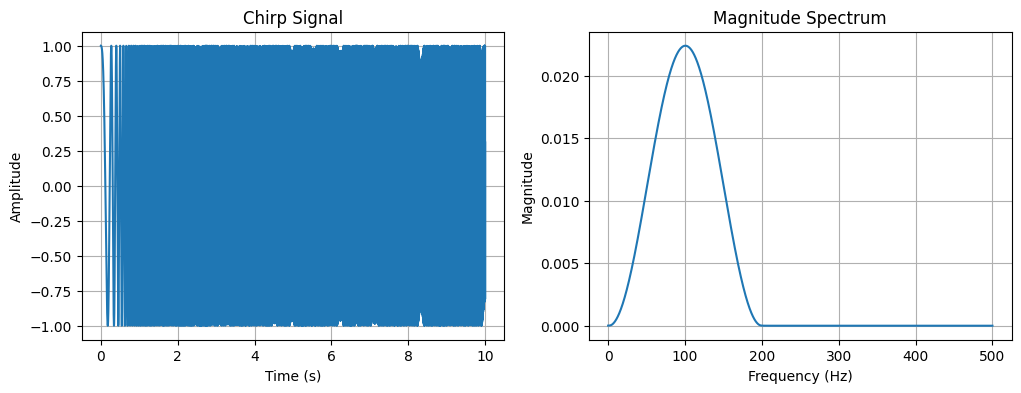

In [ ]:
fs = 1000 # Sampling frequency
tmax=10
t = np.linspace(0, tmax, tmax*fs, endpoint=False) # Time vector from 0 to 10 seconds
x = signal.chirp(t, f0=1, f1=200, t1=tmax)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Chirp Signal")
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(x, Fs=fs) #, scale="dB")
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum")
#plt.xlim(0,30)
plt.show()

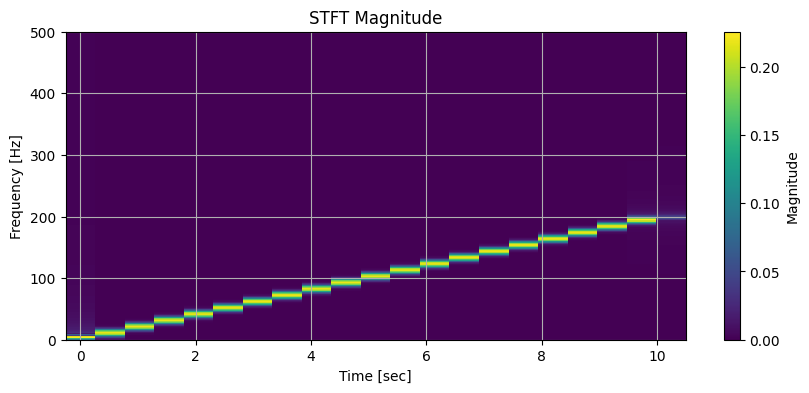

In [ ]:
f, t_stft, Zxx = signal.stft(x, fs=fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f, np.abs(Zxx), vmin=0, vmax=np.max(np.abs(Zxx)))
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

plt.ylim(0, fs/2) # Limit frequency to Nyquist
plt.colorbar(label='Magnitude')
plt.grid(True)
plt.show()

# Filtro pasa bajas

## Sistema de ORDEN 1 — RC Analógico
🔹 1A) Paso-Bajo de Primer Orden

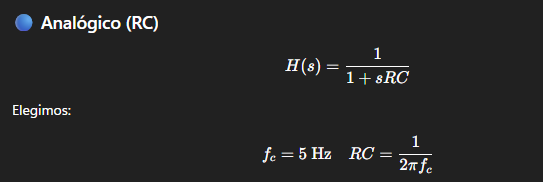

$$H(s)=\frac{1}{1+sRC}$$

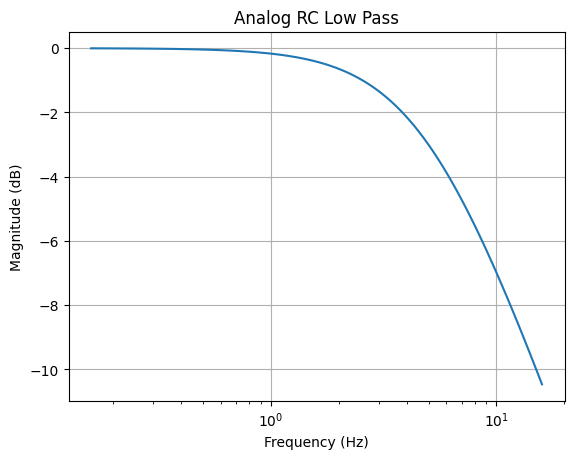

In [ ]:
fc = 5
RC = 1/(2*np.pi*fc)

num = [1]
den = [RC, 1] # sRC, 1

sys_analog = signal.TransferFunction(num, den)
w, mag, phase = signal.bode(sys_analog)

plt.figure()
plt.semilogx(w/(2*np.pi), mag)
plt.title("Analog RC Low Pass")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

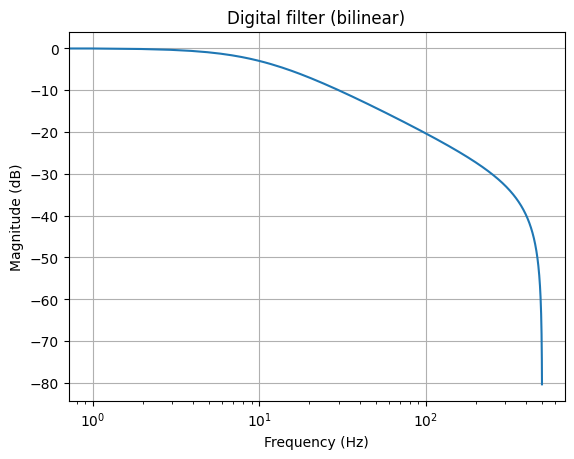

In [ ]:
#R = 1000
#C = 1e-6
#fs = 250
#T = 1/fs
fc = 10
RC = 1/(2*np.pi*fc)
fs = 1000

num = [1]
den = [RC, 1]

# Conversión bilineal
b_d, a_d = signal.bilinear(num, den, fs)

w, h = signal.freqz(b_d, a_d, fs=fs)

plt.semilogx(w, 20*np.log10(abs(h)))
plt.title("Digital filter (bilinear)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

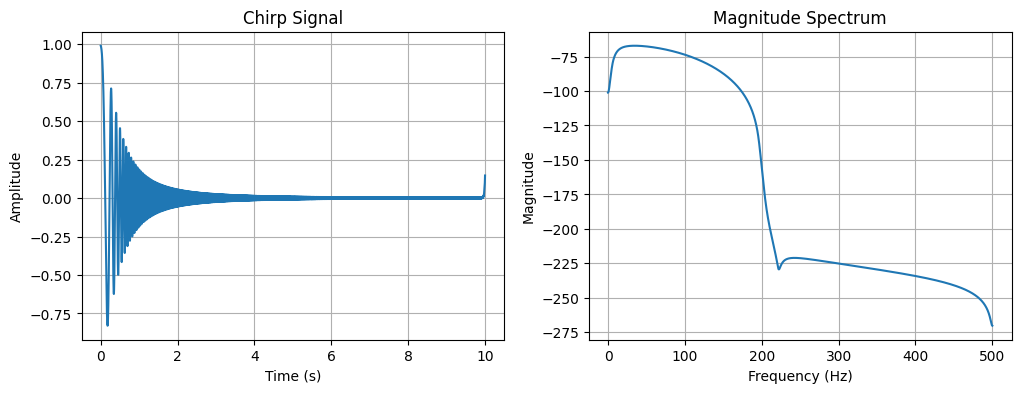

In [ ]:
y = signal.filtfilt(b_d, a_d, x)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Chirp Signal")
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(y, Fs=fs, scale="dB", )
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum")
#plt.xlim(0,30)
plt.show()

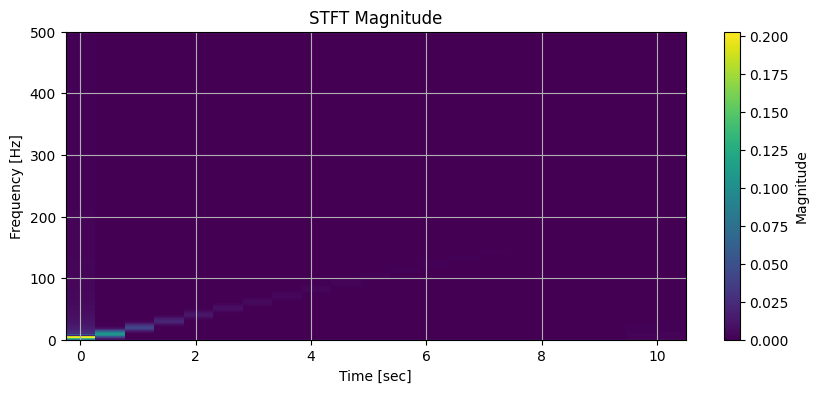

In [ ]:
f, t_stft, Zxx = signal.stft(y, fs=fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f, np.abs(Zxx), vmin=0, vmax=np.max(np.abs(Zxx)))
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

plt.ylim(0, fs/2) # Limit frequency to Nyquist
plt.colorbar(label='Magnitude')
plt.grid(True)
plt.show()

## Sistema de ORDEN 1 — RC Digital

Pasa bajas

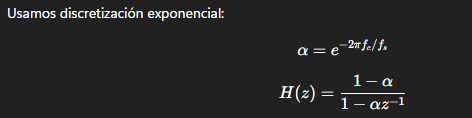

In [ ]:
fs = 1000
fc = 5

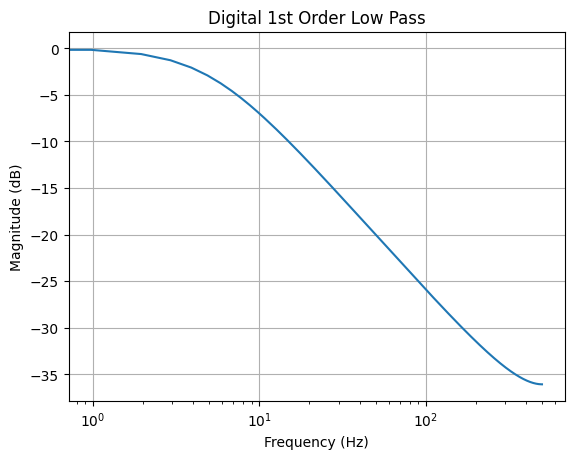

In [ ]:
alpha = np.exp(-2*np.pi*fc/fs)

b = [1-alpha]
a = [1, -alpha]

w, h = signal.freqz(b, a, fs=fs)

plt.figure()
plt.semilogx(w, 20*np.log10(abs(h)))
plt.title("Digital 1st Order Low Pass")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

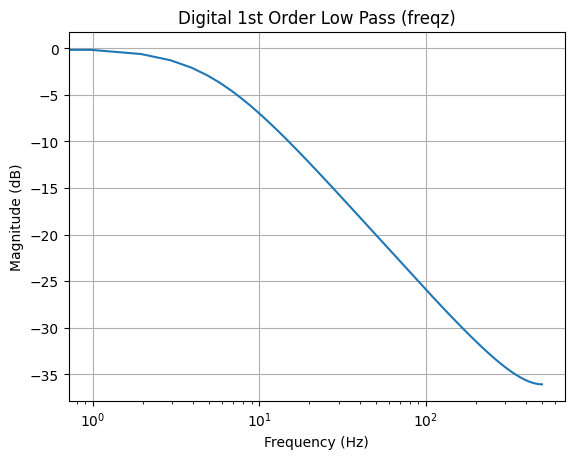

In [ ]:
# sys_digi =signal.TransferFunction(b,a,dt=1/fs) # This creates a discrete-time system
# w, mag, phase = signal.bode(sys_digi) # signal.bode is for continuous-time systems

# Use signal.freqz for discrete-time systems
w_freqz, h_freqz = signal.freqz(b, a, fs=fs)

plt.figure()
plt.semilogx(w_freqz, 20*np.log10(abs(h_freqz)))
plt.title("Digital 1st Order Low Pass (freqz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

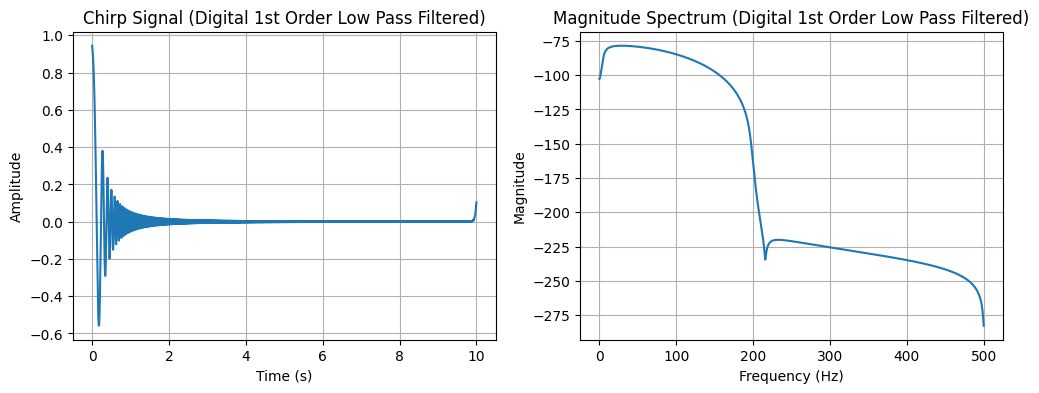

In [ ]:
y_dig = signal.filtfilt(b, a, x)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(t, y_dig)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Chirp Signal (Digital 1st Order Low Pass Filtered)")
plt.grid()

plt.subplot(1,2,2)
plt.magnitude_spectrum(y_dig, Fs=fs, scale="dB")
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum (Digital 1st Order Low Pass Filtered)")
plt.show()

# Filtro pasa altas

## Sistema de ORDEN 1 — RC Analógico


$$H(s)=\frac{sRC}{1+sRC}$$
	​


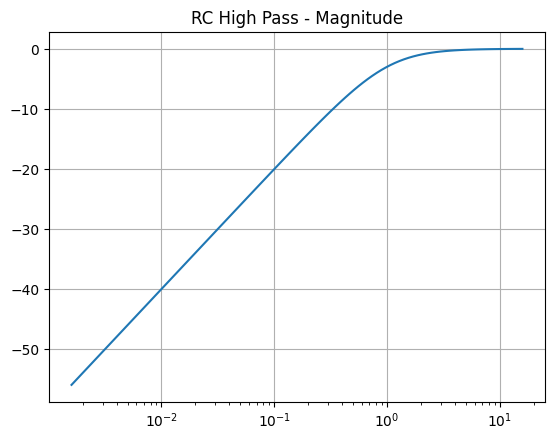

In [ ]:
#R = 1000      # 1 kΩ
#C = 1e-6      # 1 µF

fc = 1
RC = 1/(2*np.pi*fc)

num = [RC, 0]
den = [RC, 1]

system = signal.TransferFunction(num, den)
w, mag, phase = signal.bode(system)

plt.figure()
plt.semilogx(w/(2*np.pi), mag)
plt.title("RC High Pass - Magnitude")
plt.grid()
plt.show()

## Sistema de ORDEN 1 — RC Digital
Filtro paso-alto digital de 1er orden

Fórmula en LaTeX para un filtro digital paso-alto de primer orden derivado desde un paso-bajo:
 $$H(z) = \frac{\alpha - \alpha z^{-1}}{1 - \alpha z^{-1}}$$

/tmp/ipython-input-4101149910.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(w_hp_dig, 20 * np.log10(abs(h_hp_dig)))


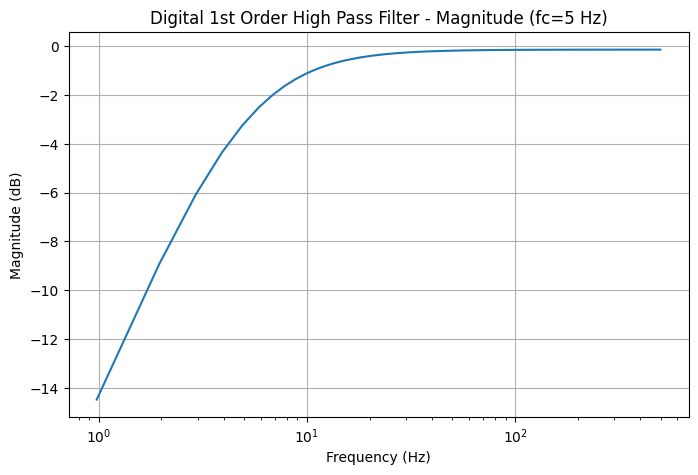

In [ ]:


# Define the cutoff frequency and sampling frequency
fc_hp_dig = 5  # Cutoff frequency for digital high-pass filter in Hz
fs = 1000      # Sampling frequency (already defined, but ensuring consistency)

# Calculate alpha for the digital filter based on the low-pass equivalent
# For a first-order digital high-pass filter, we can use the same alpha calculation
# as the low-pass and derive the coefficients as H_HP(z) = 1 - H_LP(z)
alpha_hp_dig = np.exp(-2 * np.pi * fc_hp_dig / fs)

# Coefficients for the digital high-pass filter
# Based on H(z) = (alpha - alpha*z^-1) / (1 - alpha*z^-1)
b_hp_dig = [alpha_hp_dig, -alpha_hp_dig]
a_hp_dig = [1, -alpha_hp_dig]

# Get the frequency response using signal.freqz
w_hp_dig, h_hp_dig = signal.freqz(b_hp_dig, a_hp_dig, fs=fs)

# Plot the magnitude response
plt.figure(figsize=(8, 5))
plt.semilogx(w_hp_dig, 20 * np.log10(abs(h_hp_dig)))
plt.title(f"Digital 1st Order High Pass Filter - Magnitude (fc={fc_hp_dig} Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

$$y[n]=αy[n−1]+α(x[n]−x[n−1])$$

$$α=e^{−2πfc​/fs}​$$



In [ ]:
def highpass_filter(x, alpha):
    """
    Implementación directa del filtro:
    y[n] = alpha*y[n-1] + alpha*(x[n] - x[n-1])
    """

    y = np.zeros_like(x)

    x_prev = 0.0
    y_prev = 0.0

    for n in range(len(x)):
        y[n] = alpha * y_prev + alpha * (x[n] - x_prev)

        # actualizar memorias
        x_prev = x[n]
        y_prev = y[n]

    return y

In [ ]:
fs = 1000      # frecuencia de muestreo
fc = 0.5      # frecuencia de corte

alpha = np.exp(-2*np.pi*fc/fs)
print("alpha =", alpha)

alpha = 0.9968633369849541


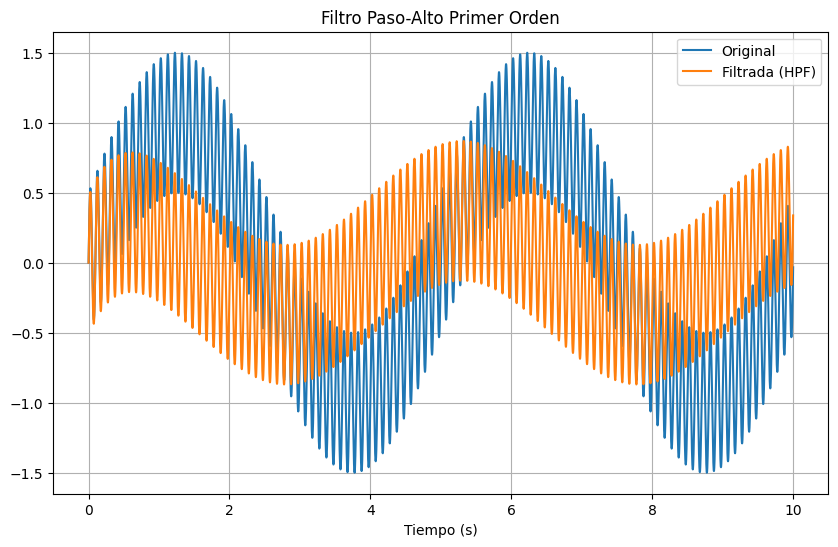

In [ ]:
t = np.arange(0, 10, 1/fs)

# señal con baja y alta frecuencia
x = np.sin(2*np.pi*0.2*t) + 0.5*np.sin(2*np.pi*10*t)

# aplicar filtro
fc = 0.5
alpha = np.exp(-2*np.pi*fc/fs)

y = highpass_filter(x, alpha)

# graficar
plt.figure(figsize=(10,6))
plt.plot(t, x, label="Original")
plt.plot(t, y, label="Filtrada (HPF)")
plt.legend()
plt.xlabel("Tiempo (s)")
plt.title("Filtro Paso-Alto Primer Orden")
plt.grid()
plt.show()

# Filtro pasa banda

## Paso-Banda de Primer Orden

aproximación en cascada

$$H(s) = \frac{s \tau}{(1 + s \tau_1)(1 + s \tau_2)}$$

### Implementar filtro analógico paso-banda


Se establecen frecuencias de corte, se calculan constantes RC, se definen los coeficientes de la función de transferencia, se crea el objeto `signal.TransferFunction` y se grafica la magnitud de Bode.



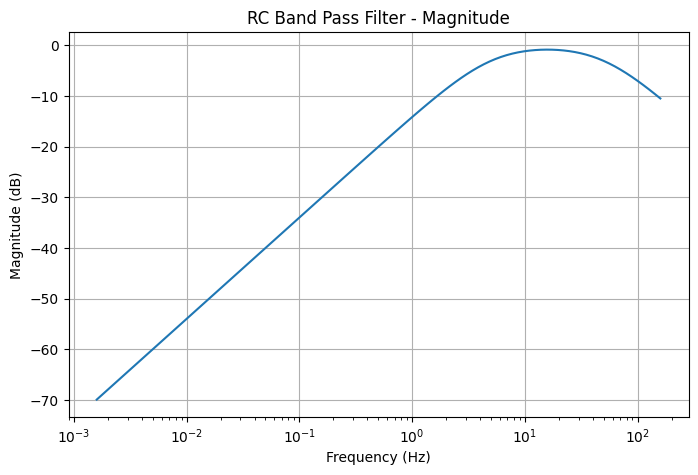

In [ ]:
fc_hp = 5 # High-pass cutoff frequency
fc_lp = 50 # Low-pass cutoff frequency

RC_hp = 1 / (2 * np.pi * fc_hp)
RC_lp = 1 / (2 * np.pi * fc_lp)

# Numerator coefficients for H(s) = (RC_hp * s)
num = [RC_hp, 0]

# Denominator coefficients for H(s) = (RC_hp * RC_lp * s^2 + (RC_hp + RC_lp) * s + 1)
den = [RC_hp * RC_lp, RC_hp + RC_lp, 1]

system_bp = signal.TransferFunction(num, den)
w_bp, mag_bp, phase_bp = signal.bode(system_bp)

plt.figure(figsize=(8,5))
plt.semilogx(w_bp/(2*np.pi), mag_bp)
plt.title("RC Band Pass Filter - Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

# Filtro rechaza-banda

### Paso-Rechaza de Primer Orden (aproximación en cascada)

$$H(s) = \frac{1 + s(RC_1 + RC_2) + s^2 RC_1 RC_2}{(1 + s RC_1)(1 + s RC_2)}$$

**Razonamiento**:
La fórmula LaTeX dada previamente para un “filtro analógico rechaza-banda de primer orden” es matemáticamente equivalente a H(s)=1, lo cual corresponde a un filtro pasa-todo (0 dB en todas las frecuencias) y no a una respuesta rechaza-banda real. Un filtro rechaza-banda verdadero normalmente requiere, como mínimo, un sistema de segundo orden. Por eso, para cumplir con el objetivo de mostrar el comportamiento rechaza-banda, se implementa un filtro notch analógico estándar de segundo orden, aclarando esta diferencia en los comentarios del código.



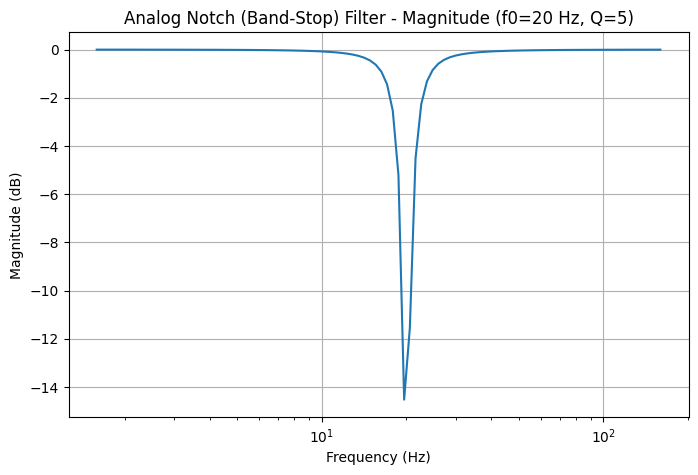

In [ ]:
# Implementing a standard second-order analog notch filter for band-stop
# A first-order analog band-stop filter is not a standard concept.

# Define notch filter parameters
f0 = 20 # Center frequency for the notch in Hz
Q = 5   # Quality factor (determines the sharpness of the notch)

omega0 = 2 * np.pi * f0 # Angular center frequency

# Transfer function for a standard analog notch filter:
# H(s) = (s^2 + omega0^2) / (s^2 + (omega0/Q)s + omega0^2)

# Numerator coefficients: [1, 0, omega0^2] for s^2, s, and constant terms
num_bs = [1, 0, omega0**2]

# Denominator coefficients: [1, omega0/Q, omega0^2] for s^2, s, and constant terms
den_bs = [1, omega0/Q, omega0**2]

system_bs = signal.TransferFunction(num_bs, den_bs)
w_bs, mag_bs, phase_bs = signal.bode(system_bs)

plt.figure(figsize=(8,5))
plt.semilogx(w_bs/(2*np.pi), mag_bs)
plt.title(f"Analog Notch (Band-Stop) Filter - Magnitude (f0={f0} Hz, Q={Q})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()